### Unequal variance is visible in ROCs
Edit the numbers marked `👈` and re-run.

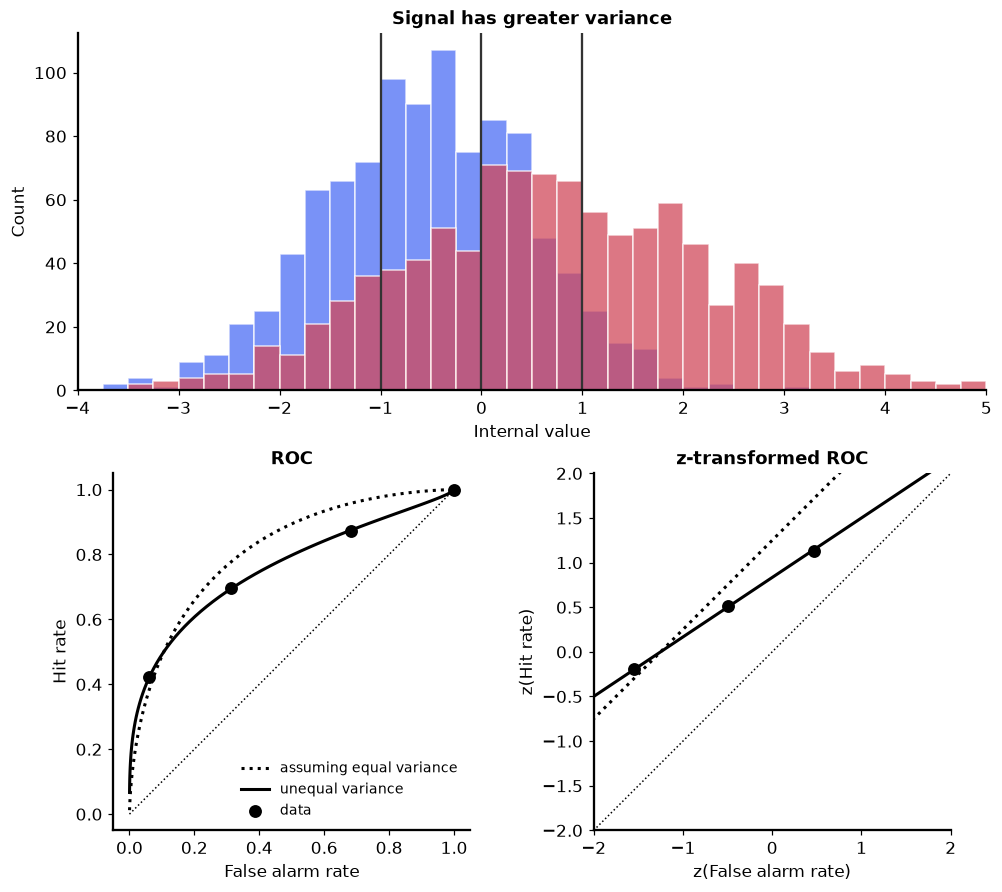

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"
SIGNAL = "#d1495b"
CRIT   = "#333333"

ntrials = 2000
psignal = 0.5
signal_mean, signal_sd = 0.75, 1.5    # 👈 signal distribution has GREATER variance
noise_mean,  noise_sd  = -0.5, 1.0    # 👈

rng = np.random.default_rng()
noise_samps  = rng.normal(noise_mean,  noise_sd,  round(ntrials * (1 - psignal)))
signal_samps = rng.normal(signal_mean, signal_sd, round(ntrials * psignal))

# a 4-point rating -> several ROC points
these_criteria = np.linspace(-1, 1, 3)
def fa_hit(noise_vals, signal_vals, criteria):
    levels = len(criteria) + 1
    rn = np.digitize(noise_vals,  criteria) + 1
    rs = np.digitize(signal_vals, criteria) + 1
    cis = np.arange(1, levels + 1)
    return (np.array([np.mean(rn >= ci) for ci in cis]),
            np.array([np.mean(rs >= ci) for ci in cis]))
fa, hit = fa_hit(noise_samps, signal_samps, these_criteria)

xs = np.linspace(-3, 3, 100)
# the (wrong) equal-variance model uses noise_sd for both
far_eq, hr_eq = 1 - norm.cdf(xs, noise_mean, noise_sd), 1 - norm.cdf(xs, signal_mean, noise_sd)
# the true unequal-variance model uses each distribution's own sd
far_un, hr_un = 1 - norm.cdf(xs, noise_mean, noise_sd), 1 - norm.cdf(xs, signal_mean, signal_sd)

fig, axd = plt.subplot_mosaic([["hist", "hist"], ["roc", "zroc"]],
                              figsize=(9, 8), constrained_layout=True)

ax = axd["hist"]
bins = np.arange(-4, 5 + 0.25, 0.25)
ax.hist(noise_samps,  bins=bins, color=NOISE,  alpha=0.75, edgecolor="white")
ax.hist(signal_samps, bins=bins, color=SIGNAL, alpha=0.75, edgecolor="white")
for c in these_criteria:
    ax.axvline(c, color=CRIT, lw=1.5)
ax.set(xlim=(-4, 5), xlabel="Internal value", ylabel="Count", title="Signal has greater variance")

ax = axd["roc"]
ax.plot(far_eq, hr_eq, color="k", lw=2, ls=":", label="assuming equal variance")
ax.plot(far_un, hr_un, color="k", lw=2, label="unequal variance")
ax.scatter(fa, hit, 55, color="k", zorder=3, label="data")
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set(xlabel="False alarm rate", ylabel="Hit rate", title="ROC"); ax.set_aspect("equal")
ax.legend(loc="lower right", fontsize=9)

ax = axd["zroc"]
ax.plot(norm.ppf(far_eq), norm.ppf(hr_eq), color="k", lw=2, ls=":")
ax.plot(norm.ppf(far_un), norm.ppf(hr_un), color="k", lw=2)
ax.scatter(norm.ppf(fa), norm.ppf(hit), 55, color="k", zorder=3)
ax.plot([-2, 2], [-2, 2], "k:", lw=1)
ax.set(xlim=(-2, 2), ylim=(-2, 2), xlabel="z(False alarm rate)", ylabel="z(Hit rate)",
       title="z-transformed ROC"); ax.set_aspect("equal")
plt.show()
